# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [38]:
pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
     |████████████████████████████████| 525 kB 22.4 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [41]:
pip install Counter


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
  Created wheel for Counter: filename=Counter-1.0.0-py3-none-any.whl size=5411 sha256=40cfd16bfe2083b113d68f919119e6278a55a1bfba4c99a10696a67f1c305302
  Stored in directory: /home/e283f3a9-8ae1-4f3d-a19f-64d8dab397e9/.cache/pip/wheels/8c/53/bd/a2a81742d0585769e6f7304ccafdd9d85b828371602b103728
Successfully built Counter
Note: you may need to restart the kernel to use updated packages.


In [42]:
pip install missingno

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [46]:
pip install sklearn-learn

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
ERROR: Could not find a version that satisfies the requirement sklearn-learn (from versions: none)
ERROR: No matching distribution found for sklearn-learn
Note: you may need to restart the kernel to use updated packages.


In [45]:
pip install textblob

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
     |████████████████████████████████| 624 kB 20.1 MB/s eta 0:00:01
     |████████████████████████████████| 1.5 MB 22.4 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [4]:

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from textblob import TextBlob
import plotly.express as px


In [5]:
df = pd.read_csv("European Restaurant Reviews.csv")

In [6]:
df.head()

,Country,Restaurant Name,Sentiment,Review Title,Review Date,Review
0,France,The Frog at Bercy Village,Negative,Rude manager,May 2024 •,The manager became agressive when I said the c...
1,France,The Frog at Bercy Village,Negative,A big disappointment,Feb 2024 •,"I ordered a beef fillet ask to be done medium,..."
2,France,The Frog at Bercy Village,Negative,Pretty Place with Bland Food,Nov 2023 •,"This is an attractive venue with welcoming, al..."
3,France,The Frog at Bercy Village,Negative,Great service and wine but inedible food,Mar 2023 •,Sadly I used the high TripAdvisor rating too ...
4,France,The Frog at Bercy Village,Negative,Avoid- Worst meal in Rome - possibly ever,Nov 2022 •,From the start this meal was bad- especially g...


In [7]:
df["Review Title"] = df["Review Title"].astype(str)
df["Review"] = df["Review"].astype(str)
df["Sentiment"] = df["Sentiment"].astype(str)

print("First 5 rows:")
print(df.head())

First 5 rows:
  Country            Restaurant Name Sentiment  \
0  France  The Frog at Bercy Village  Negative   
1  France  The Frog at Bercy Village  Negative   
2  France  The Frog at Bercy Village  Negative   
3  France  The Frog at Bercy Village  Negative   
4  France  The Frog at Bercy Village  Negative   

                                Review Title Review Date  \
0                               Rude manager  May 2024 •   
1                       A big disappointment  Feb 2024 •   
2               Pretty Place with Bland Food  Nov 2023 •   
3   Great service and wine but inedible food  Mar 2023 •   
4  Avoid- Worst meal in Rome - possibly ever  Nov 2022 •   

                                              Review  
0  The manager became agressive when I said the c...  
1  I ordered a beef fillet ask to be done medium,...  
2  This is an attractive venue with welcoming, al...  
3  Sadly I  used the high TripAdvisor rating too ...  
4  From the start this meal was bad- especially g

In this assignment, I created three visualizations using text data from a data set of European restaurant reviews. The goal was to understand what customers are saying by analyzing patterns in their review titles.
Text data is harder to visualize because it is unstructured, so I first had to clean the text before creating the visualizations

In [8]:
df.columns


Index(['Country', 'Restaurant Name', 'Sentiment', 'Review Title',
       'Review Date', 'Review'],
      dtype='object')

In [13]:
additional_stopwords = {
    "food", "restaurant", "good", "great", "best",
    "excellent", "amazing", "bad", "terrible", "place"
}

all_stopwords = set(ENGLISH_STOP_WORDS).union(additional_stopwords)

def clean_words(text):
    words = text.lower().split()
    cleaned = []
    for word in words:
        word = word.strip(string.punctuation)
        if word.isalpha() and word not in all_stopwords:
            cleaned.append(word)
    return cleaned


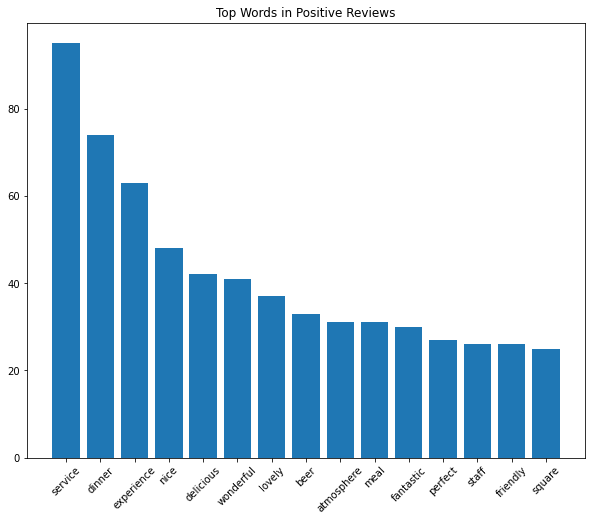

In [38]:
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

positive_word_freq = Counter(positive_words)
top_words = positive_word_freq.most_common(15)

df_words = pd.DataFrame(top_words, columns=["Word", "Frequency"])

plt.figure(figsize=(10,8))
plt.bar(df_words["Word"], df_words["Frequency"])
plt.xticks(rotation=45)
plt.title("Top Words in Positive Reviews")
plt.show()

(Positive Reviews)
This bar chart shows the most common words used in positive review titles. Each bar represents a word, and the height shows how often it appears.
This helps me see what people liked the most. If certain words show up more, it means those things stood out to customers the most, like service, experience, or food quality.

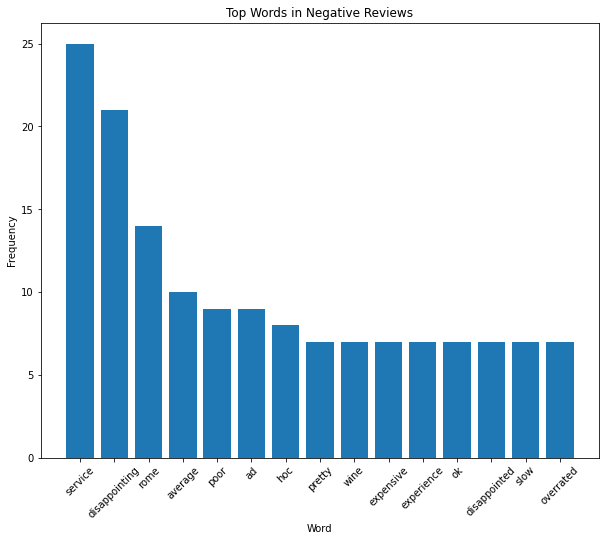

In [39]:
negative_titles = " ".join(df[df["Sentiment"] == "Negative"]["Review Title"])
negative_words = clean_words(negative_titles)

negative_freq = Counter(negative_words)
top_negative = negative_freq.most_common(15)

df_neg = pd.DataFrame(top_negative, columns=["Word", "Frequency"])

plt.figure(figsize=(10,8))
plt.bar(df_neg["Word"], df_neg["Frequency"])
plt.xticks(rotation=45)
plt.title("Top Words in Negative Reviews")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.show()

(Negative Reviews)
This bar chart shows the most common words used in negative review titles. It makes it easier to see what people complain about the most.
If words like slow, rude, or cold show up a lot, it means those are common problems. This can help restaurants know what they need to fix.

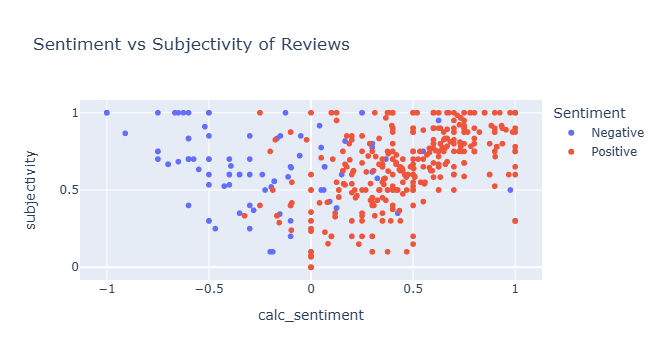

In [37]:
df["calc_sentiment"] = df["Review Title"].apply(lambda x: TextBlob(x).sentiment.polarity)
df["subjectivity"] = df["Review Title"].apply(lambda x: TextBlob(x).sentiment.subjectivity)
fig = px.scatter(
    df,
    x="calc_sentiment",
    y="subjectivity",
    color="Sentiment",
    title="Sentiment vs Subjectivity of Reviews"
)

fig.show()

Sentiment vs Subjectivity
This scatter plot shows how positive or negative each review is and how opinion-based it is. Each point represents one review.
Positive reviews are usually on the right side, and negative ones are on the left. Reviews with higher subjectivity are more emotional, while lower ones are more factual.

These visualizations helped me better understand the patterns in the text data. The word cloud shows common themes, the bar chart shows frequent complaints, and the scatter plot shows how sentiment varies across reviews.For the most part, this shows how text data can be analyzed and visualized to gain useful insights.